# Introduction to Machine Learning -- MC886
# Assignment 2 - Model Selection and Regularization

**Professor:** Marcelo da Silva Reis  
**PED:** Daniel Gardin Gratti  
**PAD:** Guilherme Henrique Ichiro Seto Ito

In [30]:
# Please, enter your name and RA number in the lines below:
print("Bruno Amaral Salles de Moraes", "|", "281129")
print("Andrei Quaresma Pinto", "|", "169194")
print("Caio Lima Albuquerque", "|", "288808") 

Bruno Amaral Salles de Moraes | 281129
Andrei Quaresma Pinto | 169194
Caio Lima Albuquerque | 288808


---

## Objective

This assignment investigates the effects of overfitting in different data regimes
and test conditions.
The goal is to understand the different results of regularization when data
availability changes, and how they impact the generalization across two different
distributions.

### Guidelines

> Please read these guidelines carefully.

1. Questions can be answered in English or in Portuguese.

2. Use data visualization as a primary tool for understanding the problem. Inspect the training data, corrupted inputs, and model behavior. When an assumption is uncertain, verify it empirically through plots.

3. The provided code serves only as a reference. Modifications are allowed, including changes to functions and the introduction of new components. Code clarity and organization are required.

4. The use of generative AI tools (e.g., ChatGPT, GitHub Copilot, DeepSeek, LLaMA) is permitted strictly for implementation support. The use of AI for interpreting, analyzing, or discussing experimental results is discouraged. Submissions must include:
   - A declaration of which models were used.
   - The prompts that generated any incorporated code.

5. Do not hesitate to reach out to the PED/PAD via Discord.

### About the Dataset

This assignment uses the [MNIST](https://web.archive.org/web/20240213122836/http://yann.lecun.com/exdb/mnist/) dataset, a standard benchmark for image classification. It consists of 28×28 grayscale images of handwritten digits (0–9), where each pixel encodes an intensity value in [0, 255].

MNIST is useful here because it is simple enough that a linear model can do well on it, which means the learned weights are directly interpretable as images, where each weight corresponds to the influence of each pixel.

To study robustness and distribution shift, this assignment uses corrupted variants from [MNIST-C](https://github.com/google-research/mnist-c), which applies systematic corruptions to the original images.

The training set consists entirely of corrupted images. The test set contains **two splits**:
- `test_corrupted`: corrupted test images (same distribution as training).
- `test_clean`: the original, uncorrupted MNIST test images.

Performance on `test_corrupted` measures how well the model learned the training task.
Performance on `test_clean` measures how well the model learned digit recognition.

Your job is to train three different models, each one with different number of
available samples:
- Full-data (60000 samples)
- Partial-data (10000 samples)
- Scarce-data (1000 samples)

Finding the best combination of hyper-parameter for each one of them.

In [31]:
from typing import Any

from numpy.typing import NDArray
import numpy as np
import pandas as pd
import random
import gc   # Garbage collector

import torch
import torch.nn as nn
from torch import optim

# Implementação do pré-processamento usa scikit-learn
from sklearn.preprocessing import StandardScaler 
from sklearn.model_selection import KFold

import matplotlib.pyplot as plt
import seaborn as sns

# Set random seeds for reproducibility.
# Do not tune this number
# Re-run the notebook from the beginning before submitting.
seed = 73   # Escolhido aleatoriamente para diferir
torch.random.manual_seed(seed)
np.random.seed(seed)
random.seed(seed)

In [32]:
# The dataset is available in the classroom assignment.
# Ensure you have downloaded it and placed it alongside this notebook.

# DO NOT change this cell

def subsample_dataset(
    X: NDArray[Any], y: NDArray[Any], n: int
) -> tuple[NDArray[Any], NDArray[Any]]:
    n_samples = len(y)

    idxs = np.random.choice(
        n_samples, size=n, replace=False
    )

    return X[idxs], y[idxs]

X_full = np.load("data/train/train_images.npy")
y_full = np.load("data/train/train_labels.npy")

X_partial, y_partial = subsample_dataset(X_full, y_full, 10_000)
X_scarce, y_scarce = subsample_dataset(X_full, y_full, 1_000)

print(f"Full-data set: {X_full.shape[0]} samples")
print(f"Partial-data set: {X_partial.shape[0]} samples")
print(f"Scarce-data set: {X_scarce.shape[0]} samples")

Full-data set: 60000 samples
Partial-data set: 10000 samples
Scarce-data set: 1000 samples


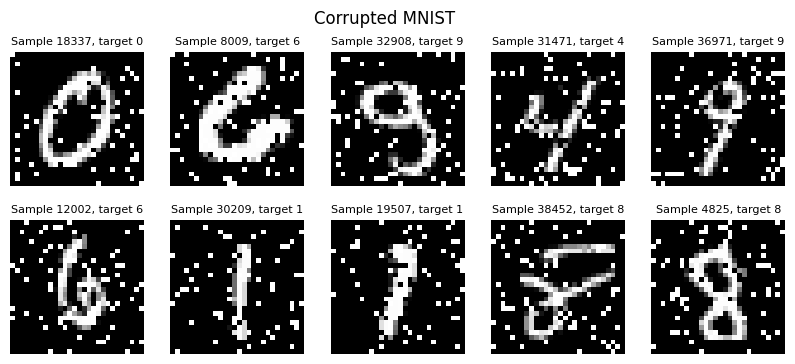

In [33]:
n_cols = 5
n_rows = 2

fig, axs = plt.subplots(nrows=n_rows, ncols=n_cols, figsize=(2*n_cols, 2*n_rows))

fig.suptitle("Corrupted MNIST")

for i in range(n_rows):
    for j in range(n_cols):
        ax = axs[i, j]
        idx = random.randint(0, len(X_full)-1)

        ax.set_title(f"Sample {idx}, target {y_full[idx]}", fontsize=8)
        ax.imshow(X_full[idx], cmap='grey')
        ax.set_axis_off()

---

## Part 1. Data Analysis and Preprocessing

### 1.1 Exploring the corruption

**(1.0 point)**

Before any modeling, understand what the corruption actually does to the data.

Is the corruption random per-pixel noise, or is it a structured perturbation?
Explore the **training** dataset, understand the distribution and the effects of the introduced
noise.

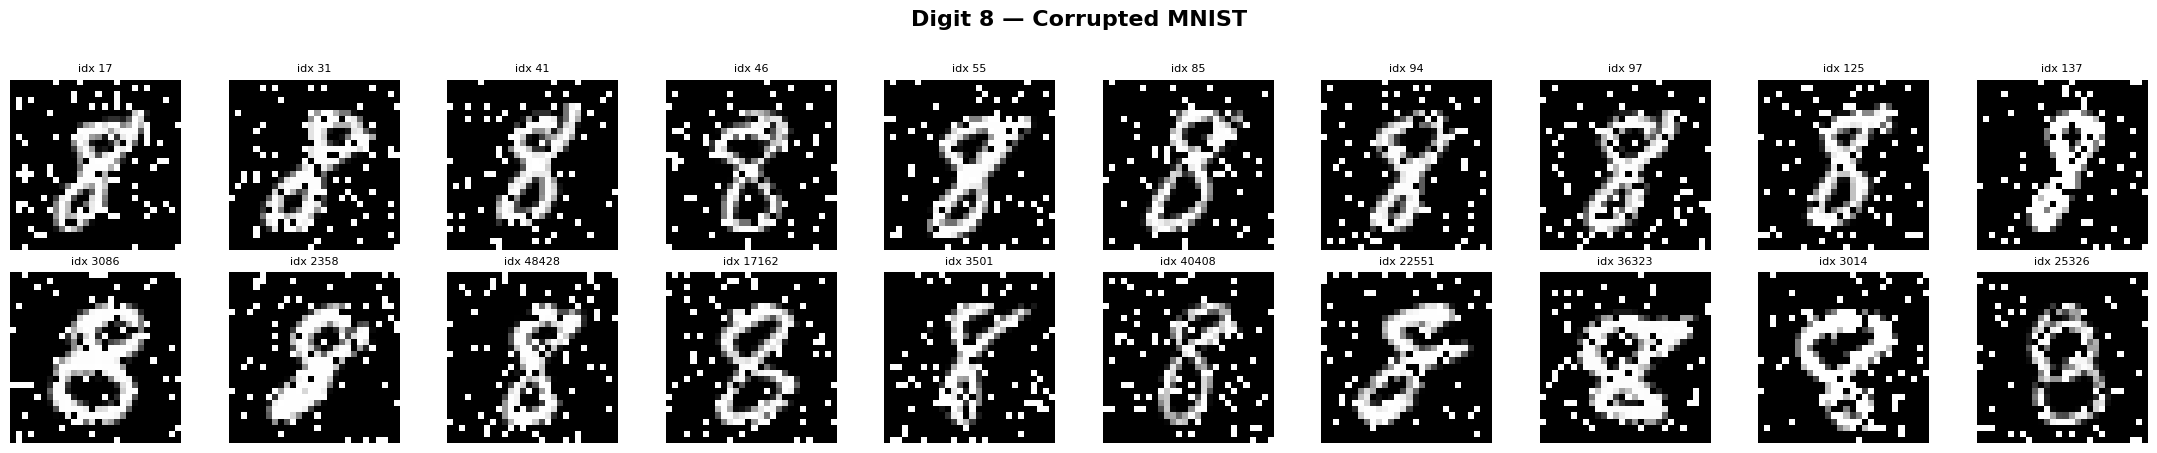

In [34]:
# Visualize digit 8: 10 sequential + 10 random samples
mask_8 = (y_full == 8)
X_8 = X_full[mask_8]
indices_8 = np.where(mask_8)[0]

n_cols = 10
n_rows = 2

fig, axs = plt.subplots(nrows=n_rows, ncols=n_cols, figsize=(2.2 * n_cols, 2.2 * n_rows))
fig.suptitle("Digit 8 — Corrupted MNIST", fontsize=16, fontweight="bold", y=1.02)

# Row 0: first 10 sequential occurrences of digit 8
for j in range(n_cols):
    ax = axs[0, j]
    global_idx = indices_8[j]
    ax.imshow(X_full[global_idx], cmap="gray")
    ax.set_title(f"idx {global_idx}", fontsize=8)
    ax.set_axis_off()
axs[0, 0].set_ylabel("Sequential", fontsize=10, rotation=90, labelpad=30)

# Row 1: 10 random samples of digit 8
random_indices = np.random.choice(len(X_8), size=n_cols, replace=False)
for j in range(n_cols):
    ax = axs[1, j]
    local_idx = random_indices[j]
    global_idx = indices_8[local_idx]
    ax.imshow(X_full[global_idx], cmap="gray")
    ax.set_title(f"idx {global_idx}", fontsize=8)
    ax.set_axis_off()
axs[1, 0].set_ylabel("Random", fontsize=10, rotation=90, labelpad=30)

plt.tight_layout()
plt.show()

Analisando um exemplo de imagem corrompida de cada dígito (0 a 9)...


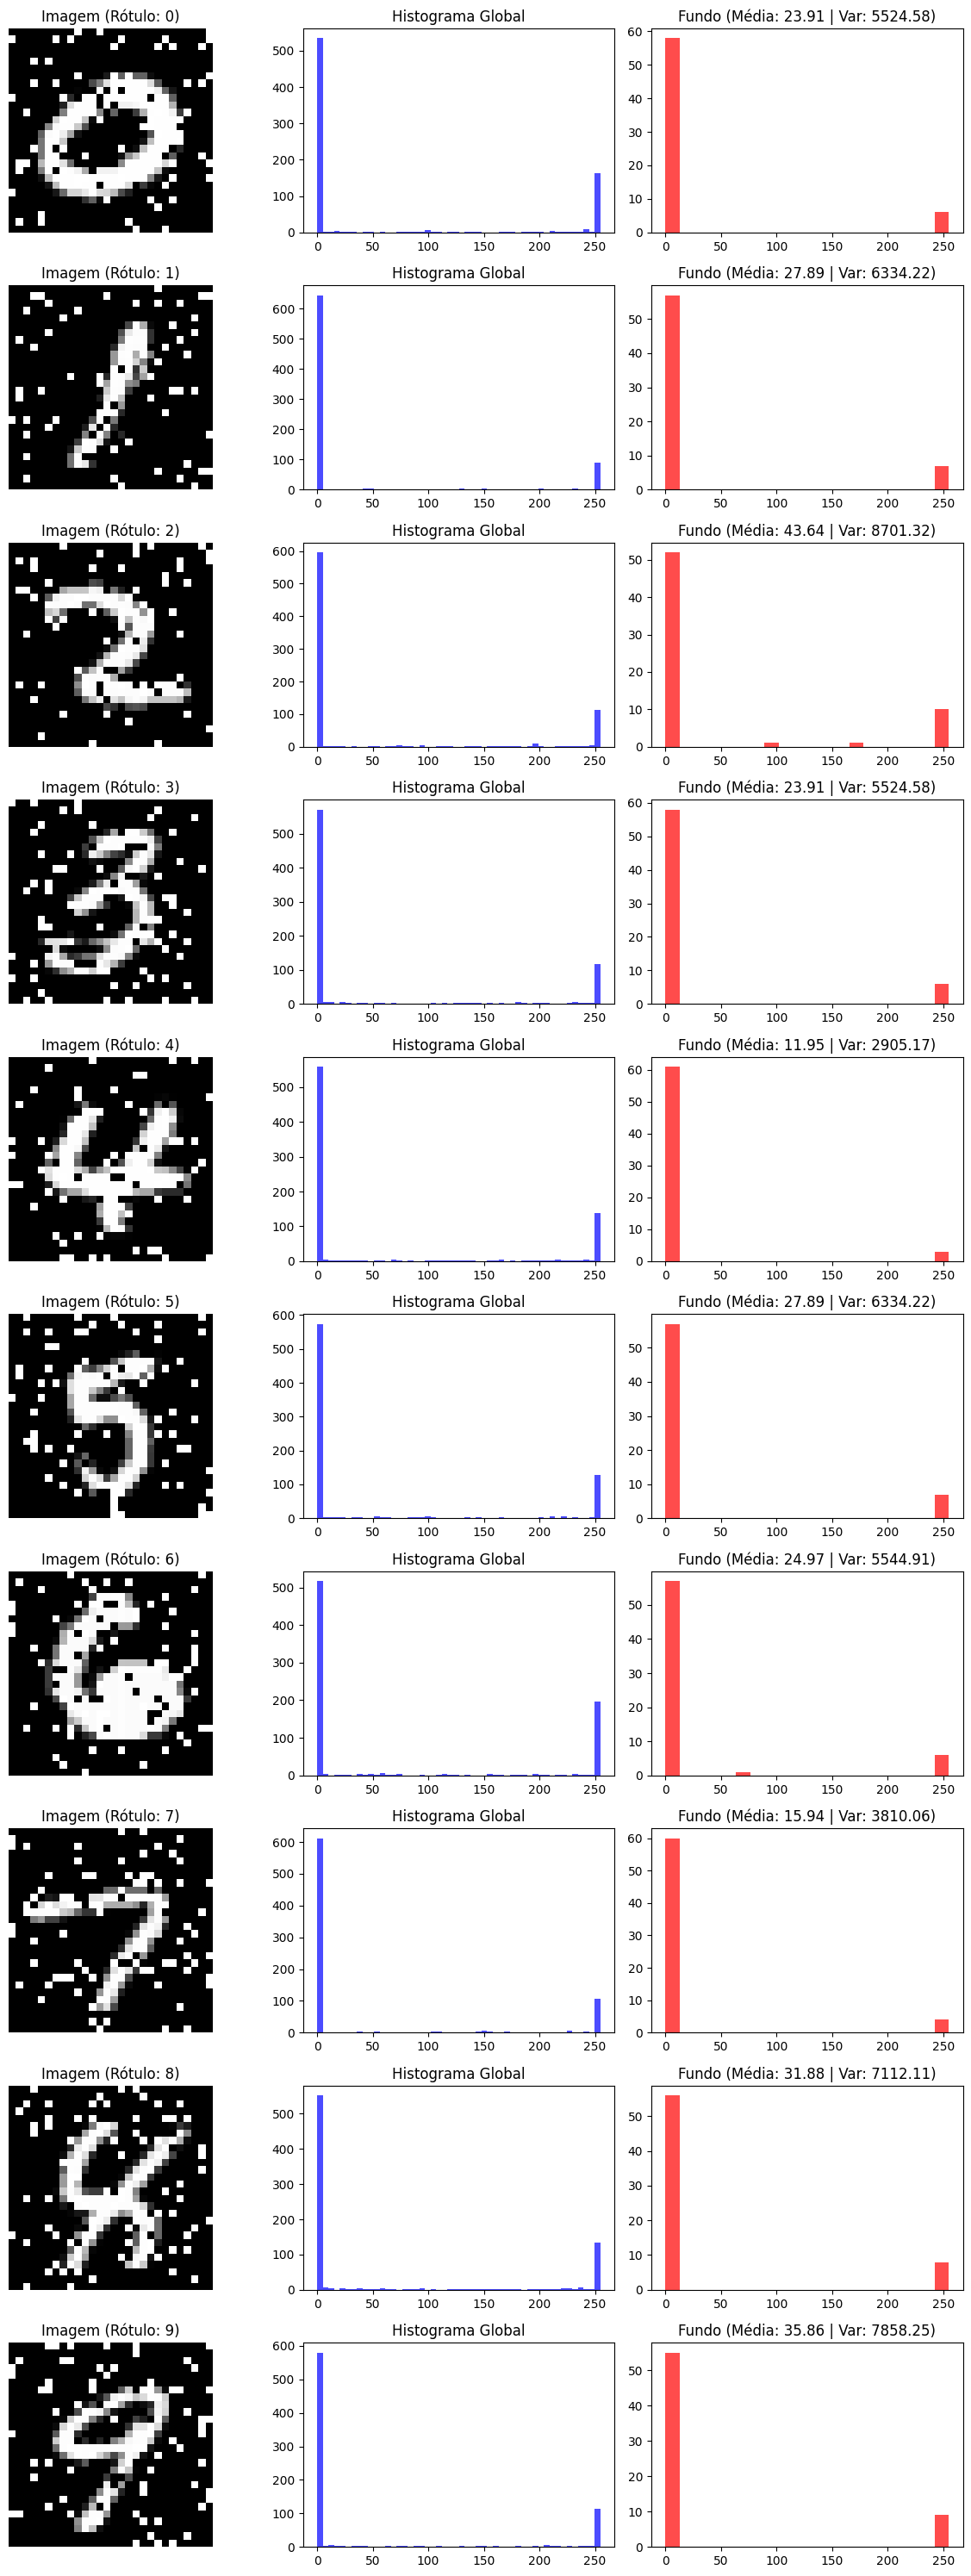

In [35]:
def analisar_ruido_mnist(imagens, rotulos=None):
    n = len(imagens)
    fig, axs = plt.subplots(nrows=n, ncols=3, figsize=(12, 3*n))
    
    for i, img in enumerate(imagens):
        # 1. Imagem Original
        titulo = f"Imagem (Rótulo: {rotulos[i]})" if rotulos is not None else "Imagem Corrompida"
        axs[i, 0].set_title(titulo)
        axs[i, 0].imshow(img, cmap='gray', vmin=0, vmax=255)
        axs[i, 0].axis('off')
        
        # 2. Histograma Global (Imagem inteira)
        axs[i, 1].set_title("Histograma Global")
        axs[i, 1].hist(img.ravel(), bins=50, color='blue', alpha=0.7)
        
        # 3. Análise do Fundo (Isolando o ruído - recorte 5x5)
        fundo_isolado = img[0:8, 0:8]
        media_fundo = np.mean(fundo_isolado)
        var_fundo = np.var(fundo_isolado)
        
        axs[i, 2].set_title(f"Fundo (Média: {media_fundo:.2f} | Var: {var_fundo:.2f})")
        axs[i, 2].hist(fundo_isolado.ravel(), bins=20, color='red', alpha=0.7)
        
    plt.tight_layout()
    plt.show()

# Recuperar um exemplo aleatório de cada número (0 a 9)
imagens_selecionadas = []
rotulos_selecionados = []

for digit in range(10):
    indices_digito = np.where(y_full == digit)[0]
    idx_aleatorio = np.random.choice(indices_digito)
    
    imagens_selecionadas.append(X_full[idx_aleatorio])
    rotulos_selecionados.append(y_full[idx_aleatorio])

print("Analisando um exemplo de imagem corrompida de cada dígito (0 a 9)...")
analisar_ruido_mnist(imagens_selecionadas, rotulos=rotulos_selecionados)

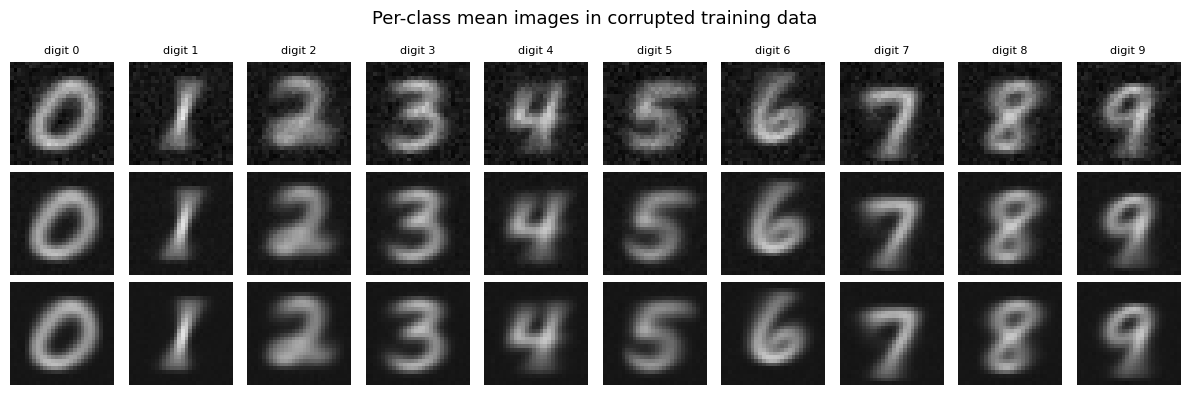

In [36]:
data_regimes = {
    "Scarce": (X_scarce, y_scarce),
    "Partial": (X_partial, y_partial),
    "Full": (X_full, y_full),
}

fig, axs = plt.subplots(len(data_regimes), 10, figsize=(4*len(data_regimes), 4))
for digit in range(10):
    axs[0, digit].set_title(f"digit {digit}", fontsize=8)

for i, name in enumerate(data_regimes):
    X, y = data_regimes[name]


    for digit in range(10):
        mask = (y == digit)
        mean_img = X[mask].mean(axis=0)
        axs[i, digit].imshow(mean_img, cmap="gray", vmin=0, vmax=255)
        axs[i, digit].axis("off")

    axs[i, 0].set_ylabel(f"{name}-data regime", fontsize=9)

plt.suptitle("Per-class mean images in corrupted training data", fontsize=13)
plt.tight_layout()
plt.show()

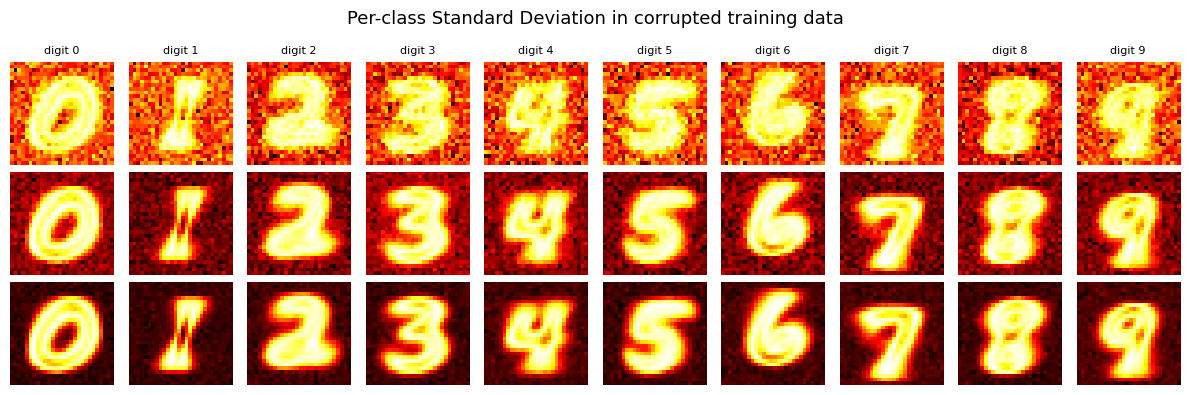

In [37]:
# Implement other visualizations to understand the corruption. 
# Visualização do Desvio Padrão (Variance/Spread of the noise)
fig, axs = plt.subplots(len(data_regimes), 10, figsize=(4*len(data_regimes), 4))
for digit in range(10):
    axs[0, digit].set_title(f"digit {digit}", fontsize=8)

for i, name in enumerate(data_regimes):
    X, y = data_regimes[name]

    for digit in range(10):
        mask = (y == digit)
        # Desvio padrão calculado ao longo do eixo das amostras
        std_img = X[mask].std(axis=0) 
        # Mapa de cores para destacar a variância
        im = axs[i, digit].imshow(std_img, cmap="hot")
        axs[i, digit].axis("off")

    axs[i, 0].set_ylabel(f"{name} (Std Dev)", fontsize=9)

plt.suptitle("Per-class Standard Deviation in corrupted training data", fontsize=13)
plt.tight_layout()
plt.show()

> **Question 1.1**
>
> Describe the corruption. Is it random and per-sample, or is it systematic and shared across images? Does it vary across digit classes?
>
> Are there data regimes where the corruption can effect more than in others?
> Hypothesize how these different regimes will affect a model trained on them.

**Natureza da corrupção:** Observando as amostras individuais no dataset, nota-se que a corrupção consiste na inversão dos valores de pixels (brancos viram pretos, pretos viram brancos) de forma dispersa (do tipo _salt and peper noise_). No dataset MNIST, espera-se um número formado por pixels brancos (valor 255) ao centro e o fundo totalmente preto (valor 0), dessa forma, ao analisar um conjunto de imagens individuais dos números, podemos ver uma variância extremamente alta dos pixels do fundo, o que indica um ruído aleatorio. Ao analisar as imagens médias e os gráficos de desvio padrão, é possível determinar que a natureza do ruído é, de fato, aleatória e independente por amostra. Ele não é um erro sistemático, como uma linha ou marca compartilhada entre as imagens, e é independente da classe, pois o padrão de distribuição do ruído não varia sistematicamente entre os diferentes dígitos.

**Efeitos:** A corrupção dos dados afeta principalmente o regime Escasso, o que se dá pois com apenas 1000 imagens, o número reduzido de amostras não é capaz de "amortizar" o efeito do ruído no treinamento. O plot do Desvio Padrão evidencia exatamente isso: no regime Escasso a variância do fundo é caótica e irregular, ou seja o ruído não se cancelou, no regime Parcial já começa a ser menor a variância e no regime Completo a média das amostras estabiliza o ruído, revelando um fundo uniforme e destacando apenas as features dos traços dos dígitos.

**Hipótese de modelagem:** Temos como hipótese que um modelo treinado com o dataset Escasso irá provavelmente sofrer overfitting, embasado pela alta variância no fundo das imagens no plot de Desvio Padrão, aprendendo a associar pixels de ruído aleatórios a classes específicas e apresentando uma performance ruim nos dados de teste sem corrupção, ou seja pouca capacidade de generalização. Por outro lado, o dataset Completo irá aprender a ignorar o ruído aleatório, já que o sinal real do dígito ser amplamente reforçado nas 60000 amostras, gerando uma melhor performance em ambos os conjuntos de teste; essa hipótese se reforça pelo fato de que, na visualização do desvio padrão para o dataset completo (última linha), o ruído é amenizado e é possível visualizar os contornos dos números claramente.

### 1.2 Preprocessing

**(1.0 point)**

Before training, the raw data must be brought into a form suitable for gradient-based optimization.

Two considerations are important here:

1. **Scale.** Raw pixel values are in [0, 255]. Gradient descent is sensitive to the scale of inputs; large input values produce large gradients, which can destabilize training.

2. **Data leakage.** Any statistics used for preprocessing must be computed from the training set only, then applied to all other splits.
Computing statistics on the full dataset, including test data, leaks information about the test distribution into preprocessing and invalidates evaluation.

In [38]:
# Implement the preprocessing on all data-regimes. You can use scikit-learn, or other libraries.

# Primeiro as imagens 2D (28x28) são achatadas em vetores 1D (784) para calcular as estatísticas por pixel corretamente
def flatten_images(X):
    return X.reshape(X.shape[0], -1)

def reshape_to_img(X):
    return X.reshape(X.shape[0], 28, 28)

# Dicionários para guardar os dados processados
X_train_processed = {}
scalers = {}

for regime_name, (X_train, y_train) in data_regimes.items():
    X_flat = flatten_images(X_train)
    
    # Inicialização do scaler
    scaler = StandardScaler()
    
    # FIT e TRANSFORM apenas no treino
    X_scaled = scaler.fit_transform(X_flat)
    
    X_train_processed[regime_name] = reshape_to_img(X_scaled)
    
    # Guarda-se o scaler de cada regime para usar no conjunto de teste depois
    scalers[regime_name] = scaler

print("Pré-processamento completo!\nEstatísticas de média e desvio padrão calculadas somente a partir dos regimes de treino.")

Pré-processamento completo!
Estatísticas de média e desvio padrão calculadas somente a partir dos regimes de treino.


> **Question 1.2**
>
> Describe the preprocessing choices made above. What strategy have you chosen, and why?

Escolhemos a estratégia de _Standardization_, ou _Z-score scaling_, usando o **StandardScaler** da biblioteca _scikit-learn_, o qual transforma os valores de intensidade de cada pixel de modo que tenham uma média $\mu = 0$ e um desvio padrão $\sigma = 1$ em todo o dataset de treino.

Essa escolha pareceu melhor pois valores de [0,255] nos pixels podem gerar uma grande variação no gradiente, tornando a otimização instável e extremamente dependente de um _learning rate_ muito baixo, ao passo que ao aplicar essa estratégia, assegura-se uma convergência mais suave, rápida e estável durante o gradiente descendente.

Além disso, para prevenção de vazamento de dados, um _scaler_ separado foi _fittado_ exclusivamente usando cada regime específico de treinos (Escasso, Parcial e Completo). Quando a etapa de validação for iniciada posteriormente, esses exatos _scalers_ serão reutilizados, garantindo que nenhuma informação estatística das distribuições de teste acabem vazando na _pipeline_, mantendo uma metodologia de validação rigorosa e correta. 

---

## Part 2. Multinomial Logistic Regression

### 2.1 The model

Multinomial logistic regression (also called softmax regression) is the natural extension of binary logistic regression to $K > 2$ classes.

Given an input $\mathbf{x} \in \mathbb{R}^d$, the model computes a score (logit) for each class $k$:

$$z_k = \mathbf{w}_k^\top \mathbf{x} + b_k$$

Each logit is an unconstrained real number, in order to transform these values into
probabilities, where $p_k \geq 0$ and $\sum_k p_k = 1$, the softmax function
is used:

$$P(y = k \mid \mathbf{x}) = \frac{e^{z_k}}{\sum_{j=1}^{K} e^{z_j}}$$

Training minimizes the **cross-entropy loss**, which is the negative log-likelihood of the true class under this distribution:

$$\mathcal{L}(\mathbf{W}, \mathbf{b}) = -\frac{1}{N} \sum_{i=1}^{N} \log P(y_i \mid \mathbf{x}_i)$$

For MNIST with $d = 784$ pixels and $K = 10$ classes, the weight matrix $\mathbf{W} \in \mathbb{R}^{10 \times 784}$ has one row per class. Each row $\mathbf{w}_k$ can be reshaped into a 28×28 image and visualized directly: positive values indicate pixels whose brightness increases the log-odds of class $k$, whereas negative values suppress it.
This direct interpretability is one reason we use a linear model here.

### 2.2 Regularization

Standard cross-entropy minimization has no preference over the parameter space.
With enough capacity, or with corrupted data that contains spurious features, the model can assign large weights to uninformative or noisy pixels if doing so reduces training loss.

Regularization considers an additional assumption over the nature of the learned weights,
adding a penalty on the weights to the loss:

$$\mathcal{L}_{\text{reg}} = \mathcal{L} + \lambda \cdot \Omega(\mathbf{W})$$

Two common choices for $\Omega$:

- **L2 (Ridge):** $\Omega(\mathbf{W}) = \|\mathbf{W}\|_2^2 = \sum_{k,j} w_{kj}^2$. Penalizes large weights uniformly, where all weights shrink toward zero but none are forced exactly to zero.
In PyTorch's optimizers, L2 is implemented as `weight_decay`.

- **L1 (Lasso):** $\Omega(\mathbf{W}) = \|\mathbf{W}\|_1 = \sum_{k,j} |w_{kj}|$. Penalizes the sum of absolute values, producing sparse solutions where many weights are driven to exactly zero.

The hyperparameter $\lambda \geq 0$ controls the strength of regularization.
$\lambda = 0$ recovers the unregularized problem.

**(2.0 point)**

Implement the Multinomial Logistic Regression model using PyTorch's nn.Module
for the linear model (image as input and logits as outputs), and SGD with both
L1 and L2 regularization methods.

In [39]:
# Implementation goes here

class LinearModel(nn.Module):
    def __init__(self, 
                 input_dim: int = 784, 
                 num_classes: int = 10):
        super().__init__()
        # A camada linear computa  W^T * x + b. 
        # Para MNIST, a entrada achatada tem 28*28 = 784 features.
        self.linear = nn.Linear(input_dim, num_classes)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # Se os dados chegarem como imagem 2D (N, 28, 28), eles serão então achatados para (N, 784)
        if x.dim() > 2:
            x = x.view(x.size(0), -1)
        
        return self.linear(x)

def accuracy(logits: torch.Tensor, y: torch.Tensor) -> float:
    """Fraction of correctly predicted samples."""
    y_pred = logits.argmax(dim=-1)
    return (y == y_pred).float().mean().item()

def train(
    model: nn.Module,
    X: torch.Tensor,
    y: torch.Tensor,
    n_iter: int,
    lr: float = 0.1,
    l1: float = 0.0,
    l2: float = 0.0
) -> list[float]:
    """
    Train a model using full-batch SGD with L1/L2 regularization.

    Returns the list of per-iteration training losses.
    """
    # Função de Perda
    criterion = nn.CrossEntropyLoss()
    
    # O PyTorch implementa a regularização L2 através do parâmetro 'weight_decay'
    optimizer = optim.SGD(model.parameters(), lr=lr, weight_decay=l2)
    
    losses = []

    print(f"Iniciando treinamento( learning_rate = {lr} ):")
    for ep in range(n_iter):
        
        # Passo Forward
        logits = model(X)
        
        # Calcular a perda base (Cross-Entropy)
        base_loss = criterion(logits, y)
        
        # Calcular a penalidade L1 (Lasso)
        l1_penalty = 0.0
        if l1 > 0.0:
            for param in model.parameters():
                l1_penalty += torch.sum(torch.abs(param))
                
        # Perda total = Perda Base + (lambda * Penalidade L1)
        loss = base_loss + (l1 * l1_penalty)
        
        # Passo Backward e Otimização
        optimizer.zero_grad()  # Limpa os gradientes do passo anterior
        loss.backward()        # Calcula os novos gradientes com backpropagation
        optimizer.step()       # Atualiza os pesos (W e b)
        
        # Salva o valor escalar da perda para visualização 
        losses.append(loss.item())

        if ep % 50 == 0: 
            print(f"   - Época: {ep}/{n_iter} | loss = {loss.item():.3f}")

    print("Treinamento finalizado")
    return losses

### 2.3 Baseline mode
**(2.0 points)**

Train a unregularized model on each training set and observe the training loss
per iteration on each model during training.

To diagnose and understand what the trained model have learned, we visualize the
learned weights as a heatmap.

Training Baseline on Scarce data...
Iniciando treinamento( learning_rate = 0.1 ):
   - Época: 0/1000 | loss = 2.440
   - Época: 50/1000 | loss = 0.181
   - Época: 100/1000 | loss = 0.085
   - Época: 150/1000 | loss = 0.055
   - Época: 200/1000 | loss = 0.040
   - Época: 250/1000 | loss = 0.032
   - Época: 300/1000 | loss = 0.026
   - Época: 350/1000 | loss = 0.022
   - Época: 400/1000 | loss = 0.019
   - Época: 450/1000 | loss = 0.017
   - Época: 500/1000 | loss = 0.015
   - Época: 550/1000 | loss = 0.014
   - Época: 600/1000 | loss = 0.013
   - Época: 650/1000 | loss = 0.012
   - Época: 700/1000 | loss = 0.011
   - Época: 750/1000 | loss = 0.010
   - Época: 800/1000 | loss = 0.010
   - Época: 850/1000 | loss = 0.009
   - Época: 900/1000 | loss = 0.008
   - Época: 950/1000 | loss = 0.008
Treinamento finalizado
-> Final Training Accuracy for Baseline (Scarce): 1.0000

Training Baseline on Partial data...
Iniciando treinamento( learning_rate = 0.1 ):
   - Época: 0/1000 | loss = 2.431
   

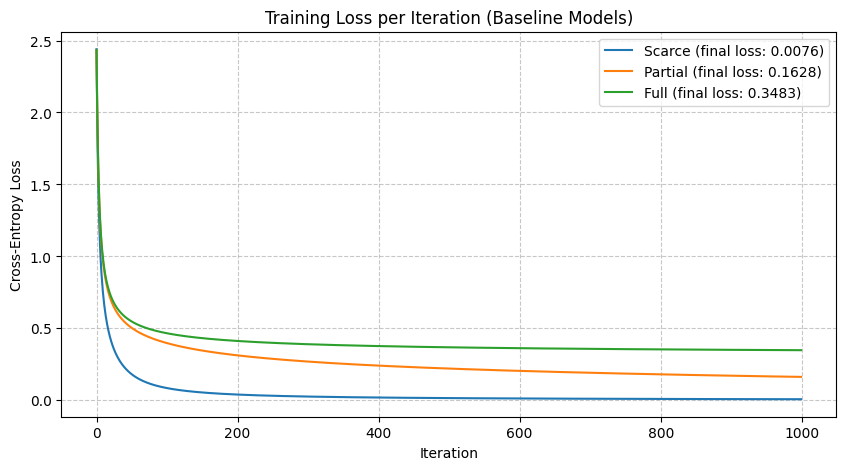

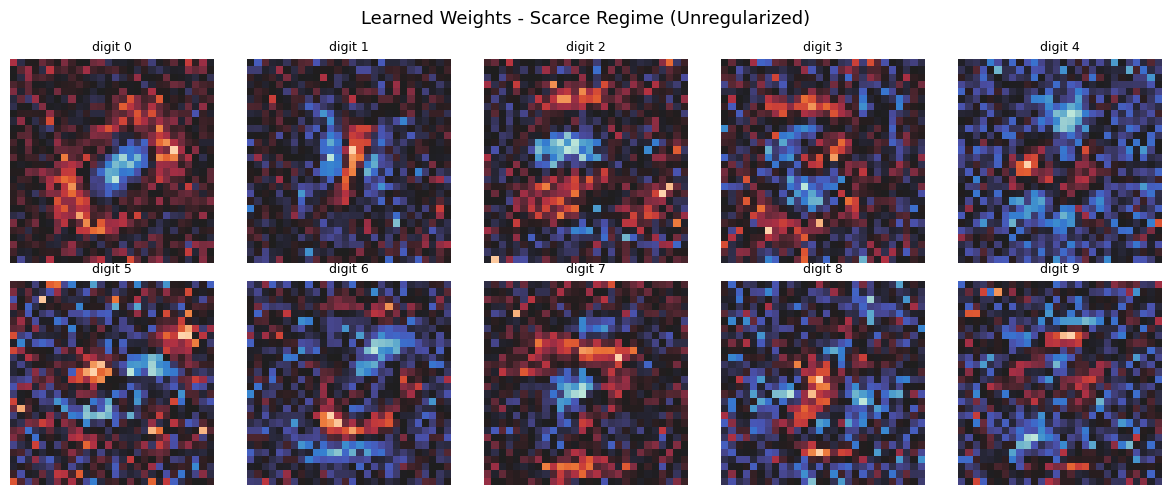

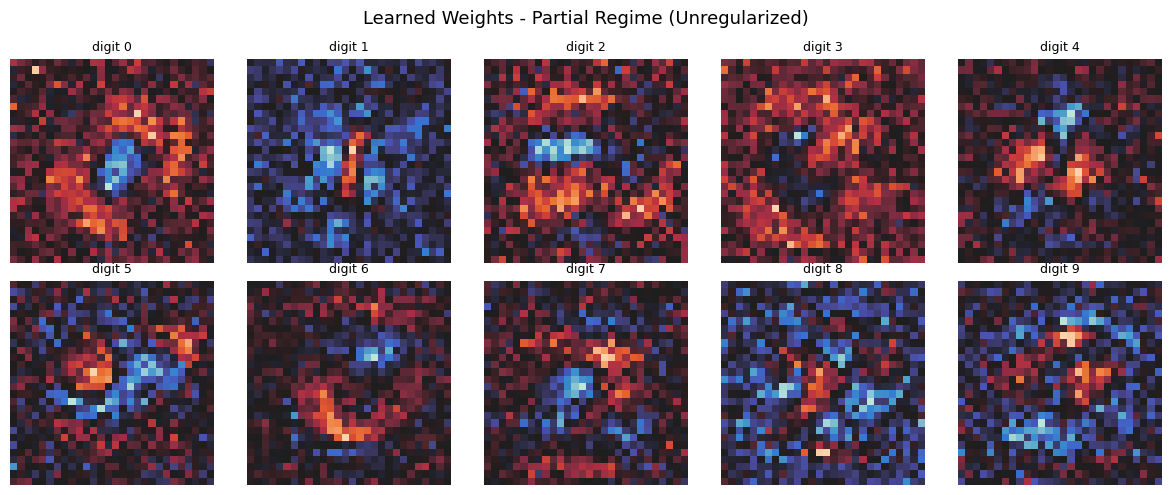

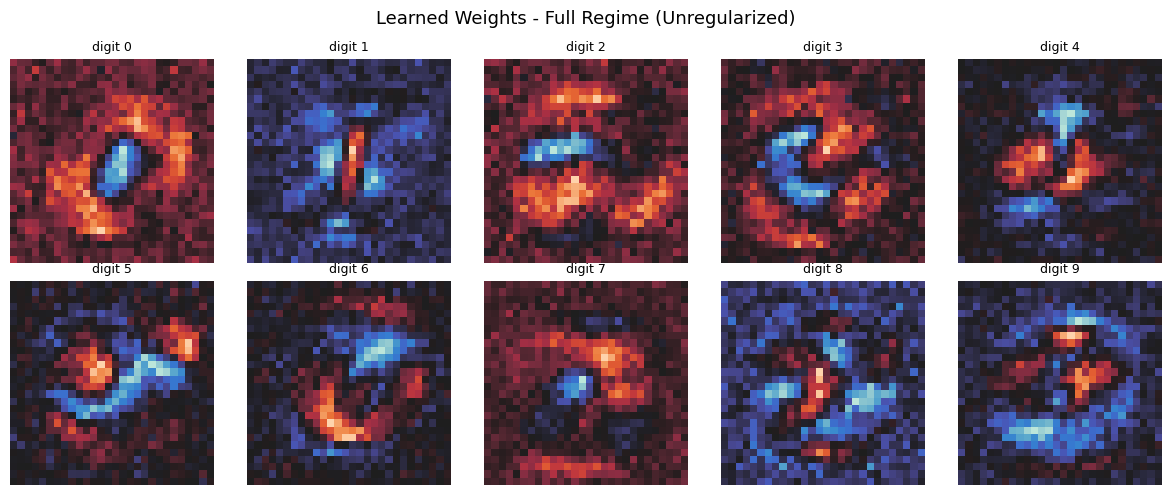

In [40]:
# Visualize learned weight images, one per digit class.
# Use a diverging colormap: red = positive weight (pixel increases log-odds),
# blue = negative weight (pixel suppresses log-odds).

def plot_weights(weights: NDArray[np.float32], title: str) -> None:
    fig, axs = plt.subplots(2, 5, figsize=(12, 5))
    fig.suptitle(title, fontsize=13)

    for digit in range(10):
        ax = axs[digit // 5, digit % 5]
        ax.imshow(weights[digit].reshape(28, 28), cmap="icefire")
        ax.set_title(f"digit {digit}", fontsize=9)
        ax.axis("off")

    plt.tight_layout()
    plt.show()


# Hiperparâmetros básicos para o Baseline
n_iters = 1000  
learning_rate = 0.1 

# Dicionários para guardar os modelos treinados e seus históricos de perdas
baseline_models = {}
baseline_losses = {}

# Treinamento dos modelos em cada regime
for regime_name in ["Scarce", "Partial", "Full"]:
    X_numpy = flatten_images(X_train_processed[regime_name]) 
    y_numpy = data_regimes[regime_name][1]
    
    X_tensor = torch.tensor(X_numpy, dtype=torch.float32)
    y_tensor = torch.tensor(y_numpy, dtype=torch.long)
    
    # Inicializando o modelo
    model = LinearModel(input_dim=784, num_classes=10)
    
    # Treinando sem regularização (L1=0, L2=0)
    print(f"Training Baseline on {regime_name} data...")
    losses = train(
        model=model, 
        X=X_tensor, y=y_tensor, 
        n_iter=n_iters, lr=learning_rate, 
        l1=0.0, l2=0.0
    )
    
    # Calculando a acurácia no próprio conjunto de treino
    with torch.no_grad():
        logits = model(X_tensor)
        train_acc = accuracy(logits, y_tensor)
    print(f"-> Final Training Accuracy for Baseline ({regime_name}): {train_acc:.4f}\n")
    
    baseline_models[regime_name] = model
    baseline_losses[regime_name] = losses

# Visualização das curvas de Loss
plt.figure(figsize=(10, 5))
for regime_name, losses in baseline_losses.items():
    plt.plot(losses, label=f"{regime_name} (final loss: {losses[-1]:.4f})")

plt.title("Training Loss per Iteration (Baseline Models)")
plt.xlabel("Iteration")
plt.ylabel("Cross-Entropy Loss")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

# Extração e visualização dos pesos aprendidos
for regime_name, model in baseline_models.items():
    weights_matrix = model.linear.weight.detach().numpy()
    
    plot_weights(weights_matrix, title=f"Learned Weights - {regime_name} Regime (Unregularized)")

In [41]:
# Cálculo da acurácia CV (K-fold) para o Baseline no regime 'Full'
print("--- Calculating K-Fold CV Accuracy for Baseline (Full Regime) ---")
kf = KFold(n_splits=5, shuffle=True, random_state=seed)
X_full_raw, y_full_raw = data_regimes["Full"]
X_full_flat = flatten_images(X_full_raw).astype(np.float32)

fold_accs = []
for train_idx, val_idx in kf.split(X_full_flat):
    X_train_flat, X_val_flat = X_full_flat[train_idx], X_full_flat[val_idx]
    y_train, y_val = y_full_raw[train_idx], y_full_raw[val_idx]
    
    # Escalonamento sem vazamento de dados
    mean = X_train_flat.mean(axis=0, keepdims=True)
    std = X_train_flat.std(axis=0, keepdims=True)
    std[std == 0] = 1.0 
    
    X_tr_t = torch.tensor((X_train_flat - mean) / std, dtype=torch.float32)
    y_tr_t = torch.tensor(y_train, dtype=torch.long)
    X_vl_t = torch.tensor((X_val_flat - mean) / std, dtype=torch.float32)
    y_vl_t = torch.tensor(y_val, dtype=torch.long)
    
    model = LinearModel(input_dim=784, num_classes=10)
    
    # Treinando sem regularização (baseline), com menos iterações para o CV
    train(model, X_tr_t, y_tr_t, n_iter=150, lr=0.1, l1=0.0, l2=0.0)
    
    with torch.no_grad():
        logits = model(X_vl_t)
        acc = accuracy(logits, y_vl_t)
        fold_accs.append(acc)
        
    del X_train_flat, X_val_flat, mean, std
    del X_tr_t, y_tr_t, X_vl_t, y_vl_t, model
    gc.collect()

baseline_cv_acc = np.mean(fold_accs)
print(f"-> Baseline CV Accuracy (Full): {baseline_cv_acc:.4f}")

del X_full_flat
gc.collect()

--- Calculating K-Fold CV Accuracy for Baseline (Full Regime) ---
Iniciando treinamento( learning_rate = 0.1 ):
   - Época: 0/150 | loss = 2.390
   - Época: 50/150 | loss = 0.542
   - Época: 100/150 | loss = 0.460
Treinamento finalizado
Iniciando treinamento( learning_rate = 0.1 ):
   - Época: 0/150 | loss = 2.451
   - Época: 50/150 | loss = 0.546
   - Época: 100/150 | loss = 0.462
Treinamento finalizado
Iniciando treinamento( learning_rate = 0.1 ):
   - Época: 0/150 | loss = 2.480
   - Época: 50/150 | loss = 0.542
   - Época: 100/150 | loss = 0.460
Treinamento finalizado
Iniciando treinamento( learning_rate = 0.1 ):
   - Época: 0/150 | loss = 2.481
   - Época: 50/150 | loss = 0.547
   - Época: 100/150 | loss = 0.463
Treinamento finalizado
Iniciando treinamento( learning_rate = 0.1 ):
   - Época: 0/150 | loss = 2.499
   - Época: 50/150 | loss = 0.545
   - Época: 100/150 | loss = 0.462
Treinamento finalizado
-> Baseline CV Accuracy (Full): 0.8627


0

> **Question 2.3**
>
> Inspect the weight images for each baseline model. How do you explain the
> weight values in the heatmap, and what patterns do they show?
>
> Compare between the model, how are they different?

A hipótese inicial era de que o dataset esparso sofreria overfitting, ao passo de que, ao aumentar o volume de samples, o modelo treinado final seria capaz de generalizar melhor a previsão para os digitos, minimizando o efeito do ruído individual de cada sample. De fato, nesse ponto, hipótese se confirma: para o dataset esparso, a representação obtida de cada dígito é extremamente ruidosa, sobretudo no fundo da imagem (em que se esperaria um fundo preto), decorando o ruído aplicado sobre a imagem no volume reduzido de amostras. A medida que o volume de dados aumenta, a distribuição dos pesos passa a ficar mais homogênea, uma vez que o gradiente passa a "amortizar" um peso positivo de um ruído com os valores negativos de um ponto preto de outra amostra. A representação dos pesos começa a tomar os contornos dos números, mas ainda com algum ruído.

Por fim, no dataset completo, o ruído tende a se anular, e a representação dos numeros passa a aparecer de forma muito mais clara nos pesos aprendidos e tomam formas delimitadas dos números. Espera-se que esse modelo tenha capacidade melhor de generalização em comparação aos demais.

---

## Part 3. Regularization

**(2.0 points)**

We now introduce regularization and sweep over $\lambda$ values for both L1 and L2 penalties.

Your **only decision criterion** in this part is cross-validation accuracy computed on the corrupted training data, exactly what you would have in a real scenario without access to an unlabeled clean test set.

For each configuration (data regime x reg type x $\lambda$), use K-fold cross-validation to estimate validation accuracy.
Then, for each regularizer, **select the best $\lambda$** by CV and train a final model on the full training set.
Store the final models, they will be evaluated after model selection is complete.

> **Decision task** Report, per regularizer and data regimes, which $\lambda$ you selected and why.
Inspect the weight images of your chosen models and describe what you observe.


In [42]:
# Implement K-fold cross-validation with correct pre-processing
def run_kfold_cv(X_raw: NDArray[Any], y_raw: NDArray[Any], reg_type: str, k_splits: int, lambda_grid: list):
    """
    Função de Cross-Validation utilizando k-fold 
    """
    kf = KFold(n_splits=k_splits, shuffle=True, random_state=seed)
    best_lambda = 0.0
    best_acc = 0.0
    cv_results = {}
    
    X_raw_flat = flatten_images(X_raw).astype(np.float32)
    
    for lbd in lambda_grid:
        fold_accs = []
        for train_idx, val_idx in kf.split(X_raw_flat):
            X_train_flat, X_val_flat = X_raw_flat[train_idx], X_raw_flat[val_idx]
            y_train, y_val = y_raw[train_idx], y_raw[val_idx]
            
            # --- ESCALONAMENTO MANUAL (Bypass do StandardScaler) ---
            # Isso evita o pico de memória "escondido" do Scikit-Learn em float64
            mean = X_train_flat.mean(axis=0, keepdims=True)
            std = X_train_flat.std(axis=0, keepdims=True)
            std[std == 0] = 1.0 # Evita divisão por zero em pixels totalmente pretos
            
            # Aplica Z-score e cria tensores na mesma linha
            X_tr_t = torch.tensor((X_train_flat - mean) / std, dtype=torch.float32)
            y_tr_t = torch.tensor(y_train, dtype=torch.long)
            X_vl_t = torch.tensor((X_val_flat - mean) / std, dtype=torch.float32)
            y_vl_t = torch.tensor(y_val, dtype=torch.long)
            # -------------------------------------------------------
                        
            model = LinearModel(input_dim=784, num_classes=10)
            l1_val = lbd if reg_type == 'l1' else 0.0
            l2_val = lbd if reg_type == 'l2' else 0.0
            
            # Menos iterações no CV para economizar tempo
            train(model, X_tr_t, y_tr_t, n_iter=150, lr=0.1, l1=l1_val, l2=l2_val)
            
            # Avaliação no fold de validação
            with torch.no_grad():
                logits = model(X_vl_t)
                acc = accuracy(logits, y_vl_t)
                fold_accs.append(acc)
                
            # Limpando variáveis criadas no loop interno para limperza de memória
            del X_train_flat, X_val_flat, mean, std
            del X_tr_t, y_tr_t, X_vl_t, y_vl_t, model
            gc.collect()
            
        # Média das dobras para este lambda
        avg_acc = np.mean(fold_accs)
        cv_results[lbd] = avg_acc
        
        # Atualiza o melhor
        if avg_acc > best_acc:
            best_acc = avg_acc
            best_lambda = lbd

    # Remoção do dataset achatado após o final da CV
    del X_raw_flat
    gc.collect()
            
    return best_lambda, cv_results

In [43]:
# Definindo o grid de busca para lambda
lambda_grid = [0.0001, 0.001, 0.01, 0.1, 1.0, 10.0]
k_splits = 5

# Dicionários para armazenar os melhores modelos e resultados
best_lambdas = {"l1": {}, "l2": {}}
final_models = {"l1": {}, "l2": {}}
cv_curves = {"l1": {}, "l2": {}}

for reg_type in ["l1", "l2"]:
    for regime in ["Scarce", "Partial", "Full"]:
        print(f"Running CV for {reg_type.upper()} on {regime} regime...")
        X_raw, y_raw = data_regimes[regime]
        
        best_lbd, results = run_kfold_cv(X_raw, y_raw, reg_type, k_splits, lambda_grid)
        best_lambdas[reg_type][regime] = best_lbd
        cv_curves[reg_type][regime] = results
        
        print(f"  Melhor lambda: {best_lbd} (CV Acc: {results[best_lbd]:.4f})")
        
        # Treinando o modelo final com todos os dados do regime e o melhor lambda
        print(f"  Treinando modelo final...")

        # Escalonamento manual otimizado para o modelo final
        X_raw_flat = flatten_images(X_raw).astype(np.float32)
        mean = X_raw_flat.mean(axis=0, keepdims=True)
        std = X_raw_flat.std(axis=0, keepdims=True)
        std[std == 0] = 1.0
        
        X_t = torch.tensor((X_raw_flat - mean) / std, dtype=torch.float32)
        y_t = torch.tensor(y_raw, dtype=torch.long)
        
        del X_raw_flat, mean, std
        gc.collect()

        final_model = LinearModel()
        l1_val = best_lbd if reg_type == 'l1' else 0.0
        l2_val = best_lbd if reg_type == 'l2' else 0.0
        
        train(final_model, X_t, y_t, n_iter=1000, lr=0.1, l1=l1_val, l2=l2_val)
        final_models[reg_type][regime] = final_model

        # Limpeza de variáveis do loop interno após cada treinamento
        del X_t, y_t
        gc.collect()

Running CV for L1 on Scarce regime...
Iniciando treinamento( learning_rate = 0.1 ):
   - Época: 0/150 | loss = 2.465
   - Época: 50/150 | loss = 0.166
   - Época: 100/150 | loss = 0.092
Treinamento finalizado
Iniciando treinamento( learning_rate = 0.1 ):
   - Época: 0/150 | loss = 2.527
   - Época: 50/150 | loss = 0.171
   - Época: 100/150 | loss = 0.094
Treinamento finalizado
Iniciando treinamento( learning_rate = 0.1 ):
   - Época: 0/150 | loss = 2.369
   - Época: 50/150 | loss = 0.169
   - Época: 100/150 | loss = 0.093
Treinamento finalizado
Iniciando treinamento( learning_rate = 0.1 ):
   - Época: 0/150 | loss = 2.500
   - Época: 50/150 | loss = 0.167
   - Época: 100/150 | loss = 0.092
Treinamento finalizado
Iniciando treinamento( learning_rate = 0.1 ):
   - Época: 0/150 | loss = 2.540
   - Época: 50/150 | loss = 0.173
   - Época: 100/150 | loss = 0.095
Treinamento finalizado
Iniciando treinamento( learning_rate = 0.1 ):
   - Época: 0/150 | loss = 2.515
   - Época: 50/150 | loss = 

<>:17: SyntaxWarning: invalid escape sequence '\l'
<>:23: SyntaxWarning: invalid escape sequence '\l'
<>:24: SyntaxWarning: invalid escape sequence '\l'
<>:17: SyntaxWarning: invalid escape sequence '\l'
<>:23: SyntaxWarning: invalid escape sequence '\l'
<>:24: SyntaxWarning: invalid escape sequence '\l'
C:\Users\Master\AppData\Local\Temp\ipykernel_20288\398890140.py:17: SyntaxWarning: invalid escape sequence '\l'
  label=f"{regime} ({reg_type.upper()}) | Best $\lambda$: {best_l} (Acc: {best_acc:.4f})")
C:\Users\Master\AppData\Local\Temp\ipykernel_20288\398890140.py:23: SyntaxWarning: invalid escape sequence '\l'
  plt.title("Cross-Validation Accuracy vs $\lambda$ (All Regimes and Regularizations)")
C:\Users\Master\AppData\Local\Temp\ipykernel_20288\398890140.py:24: SyntaxWarning: invalid escape sequence '\l'
  plt.xlabel("$\lambda$ (log scale)")


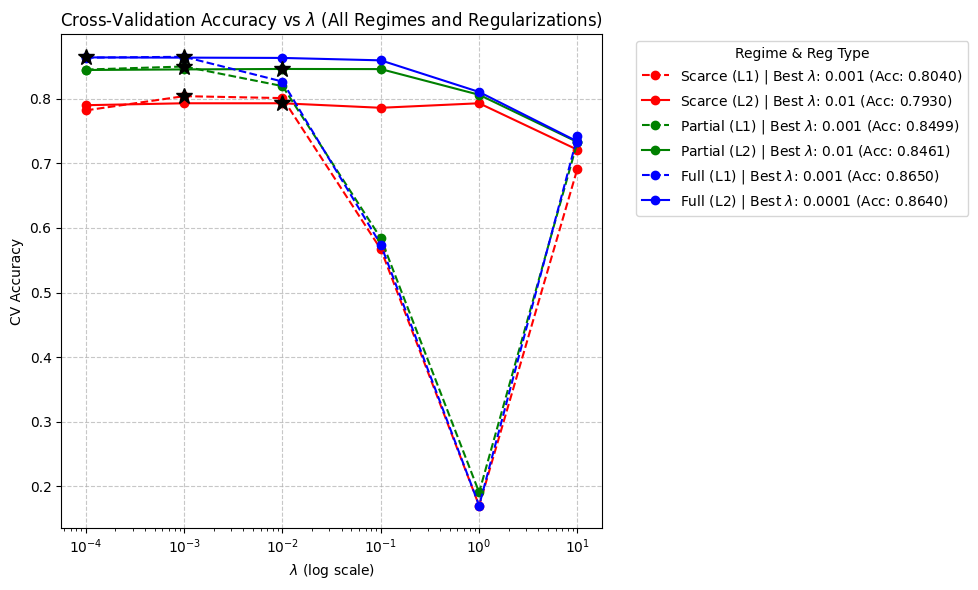

In [44]:
# 1. Visualização das Curvas de Validação Cruzada
plt.figure(figsize=(10, 6))

colors = {"Scarce": "red", "Partial": "green", "Full": "blue"}
linestyles = {"l1": "--", "l2": "-"}

for regime in ["Scarce", "Partial", "Full"]:
    for reg_type in ["l1", "l2"]:
        lambdas = list(cv_curves[reg_type][regime].keys())
        accs = list(cv_curves[reg_type][regime].values())
        
        best_l = best_lambdas[reg_type][regime]
        best_acc = cv_curves[reg_type][regime][best_l]
        
        # Plota a curva usando cor indicando regime e estilo de linha indicando regularização
        plt.plot(lambdas, accs, marker='o', color=colors[regime], linestyle=linestyles[reg_type], 
                 label=f"{regime} ({reg_type.upper()}) | Best $\lambda$: {best_l} (Acc: {best_acc:.4f})")
        
        # Marca o melhor lambda encontrado com uma estrela preta
        plt.plot(best_l, best_acc, marker='*', color='black', markersize=12, zorder=5)

plt.xscale('log')
plt.title("Cross-Validation Accuracy vs $\lambda$ (All Regimes and Regularizations)")
plt.xlabel("$\lambda$ (log scale)")
plt.ylabel("CV Accuracy")
plt.legend(title="Regime & Reg Type", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()



a) Analisando a acurácia da classificação em relação aos valores de lambda, obtemos o seguinte gráfico:

![image.png](attachment:image.png)

Para os valores de lambda de L2 (linhas contínuas do gráfico), obtivemos o resultado esperado de que o treinamento com dataset completo tem resultado superior aos demais, enquanto o dataset esparso tem resultado pior. Durante a validação cruzada, a acurácia se manteve estável e alta, atingindo um plato para valores pequenos de Lambda (10⁻4 a 10⁻1). Para valores maiores, a acurácia começa a diminuir: Nesses cenários, a regularização se torna muito acentuada e passa a diminuir excessivamente os pesos. A curva forma claramente um plato para valores menores de lambda.


---

## Part 4. Test

**(2.0 points)**

Until now, all decisions, dataset size analysis, regularization selection, were made using only the corrupted training data and cross-validation.
**Now we use the test sets** to evaluate the models you selected.

In [45]:
# Load the test dataset and evaluate all the chosen models for each data regime
X_test_corr_raw = np.load("data/test/test_images.npy")
y_test_corr_raw = np.load("data/test/test_labels.npy")

X_test_clean_raw = np.load("data/test/clean_images.npy")
y_test_clean_raw = np.load("data/test/clean_labels.npy")

y_t_corr = torch.tensor(y_test_corr_raw, dtype=torch.long)
y_t_clean = torch.tensor(y_test_clean_raw, dtype=torch.long)

X_test_corr_flat = flatten_images(X_test_corr_raw).astype(np.float32)
X_test_clean_flat = flatten_images(X_test_clean_raw).astype(np.float32)

# As imagens cruas já foram achatadas e não serão mais usadas 
del X_test_corr_raw, X_test_clean_raw
gc.collect()

16370

In [46]:
# Função para calcular a esparsidade (Sparsity)
def calculate_sparsity(model: nn.Module, threshold: float = 1e-4) -> float:
    """Calcula a porcentagem de pesos que são praticamente zero."""
    weights = model.linear.weight.detach().numpy()
    zeros = np.sum(np.abs(weights) < threshold)
    total = weights.size
    return zeros / total

In [47]:
# Dicionários para guardar os resultados de teste dos modelos finais (selecionados via CV)
final_test_results = {"Scarce": {}, "Partial": {}, "Full": {}}

print("--- Evaluating Final CV-Selected Models ---")
for regime in ["Scarce", "Partial", "Full"]:
    # Prepara os dados de treino achatados
    X_train_flat = flatten_images(data_regimes[regime][0]).astype(np.float32)
    mean = X_train_flat.mean(axis=0, keepdims=True)
    std = X_train_flat.std(axis=0, keepdims=True)
    std[std == 0] = 1.0

    # Após conseguir a média e o desvio, descarta-se o treino
    del X_train_flat
    gc.collect()

    # Aplicando a fórmula Z-score manualmente nos testes
    X_tc = torch.tensor((X_test_corr_flat - mean) / std, dtype=torch.float32)
    X_tcl = torch.tensor((X_test_clean_flat - mean) / std, dtype=torch.float32)
    
    del mean, std
    gc.collect()
    
    for reg_type in ["l1", "l2"]:
        model = final_models[reg_type][regime]
        
        with torch.no_grad():
            acc_corr = accuracy(model(X_tc), y_t_corr)
            acc_clean = accuracy(model(X_tcl), y_t_clean)
            sparsity = calculate_sparsity(model)
            
        final_test_results[regime][reg_type] = {
            "acc_corr": acc_corr, "acc_clean": acc_clean, "sparsity": sparsity
        }
        print(f"[{regime} | {reg_type.upper()}] Acc Corr: {acc_corr:.4f} | Acc Clean: {acc_clean:.4f} | Sparsity: {sparsity:.2%}")

    # Liberação de últimas variáveis do loop interno antes de seguir para o próximo regime
    del X_tc, X_tcl
    gc.collect()

--- Evaluating Final CV-Selected Models ---
[Scarce | L1] Acc Corr: 0.7987 | Acc Clean: 0.8471 | Sparsity: 49.23%
[Scarce | L2] Acc Corr: 0.7940 | Acc Clean: 0.8451 | Sparsity: 0.20%
[Partial | L1] Acc Corr: 0.8573 | Acc Clean: 0.8849 | Sparsity: 40.64%
[Partial | L2] Acc Corr: 0.8474 | Acc Clean: 0.8822 | Sparsity: 0.19%
[Full | L1] Acc Corr: 0.8857 | Acc Clean: 0.8963 | Sparsity: 50.70%
[Full | L2] Acc Corr: 0.8767 | Acc Clean: 0.8963 | Sparsity: 0.22%


Iniciando treinamento( learning_rate = 0.1 ):
   - Época: 0/250 | loss = 2.511
   - Época: 50/250 | loss = 0.204
   - Época: 100/250 | loss = 0.111
   - Época: 150/250 | loss = 0.082
   - Época: 200/250 | loss = 0.069
Treinamento finalizado
Iniciando treinamento( learning_rate = 0.1 ):
   - Época: 0/250 | loss = 2.559
   - Época: 50/250 | loss = 0.381
   - Época: 100/250 | loss = 0.304
   - Época: 150/250 | loss = 0.280
   - Época: 200/250 | loss = 0.268
Treinamento finalizado
Iniciando treinamento( learning_rate = 0.1 ):
   - Época: 0/250 | loss = 3.843
   - Época: 50/250 | loss = 1.184
   - Época: 100/250 | loss = 1.119
   - Época: 150/250 | loss = 1.095
   - Época: 200/250 | loss = 1.083
Treinamento finalizado
Iniciando treinamento( learning_rate = 0.1 ):
   - Época: 0/250 | loss = 16.457
   - Época: 50/250 | loss = 6.026
   - Época: 100/250 | loss = 6.011
   - Época: 150/250 | loss = 6.025
   - Época: 200/250 | loss = 6.041
Treinamento finalizado
Iniciando treinamento( learning_rat

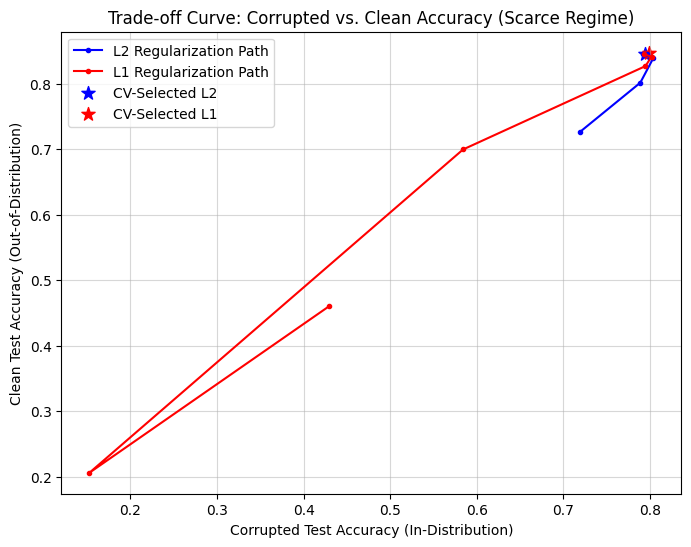

In [48]:
# Curva de Trade-off (apenas para o regime Scarce como exemplo analítico)
tradeoff_results = {"l1": {"corr": [], "clean": []}, "l2": {"corr": [], "clean": []}}

# Escolhe-se o regime Scarce para ilustrar o trade-off severo
scaler_scarce = StandardScaler().fit(flatten_images(data_regimes["Scarce"][0]))
X_tc_scarce = torch.tensor(scaler_scarce.transform(flatten_images(X_test_corr_flat)), dtype=torch.float32)
X_tcl_scarce = torch.tensor(scaler_scarce.transform(flatten_images(X_test_clean_flat)), dtype=torch.float32)

for reg_type in ["l1", "l2"]:
    for lbd in lambda_grid:
        # Treinando um modelo rápido para cada lambda no regime Scarce
        temp_model = LinearModel()
        X_train_scarce_t = torch.tensor(scaler_scarce.transform(flatten_images(data_regimes["Scarce"][0])), dtype=torch.float32)
        y_train_scarce_t = torch.tensor(data_regimes["Scarce"][1], dtype=torch.long)
        
        train(temp_model, X_train_scarce_t, y_train_scarce_t, n_iter=250, lr=0.1, 
              l1=(lbd if reg_type=='l1' else 0.0), l2=(lbd if reg_type=='l2' else 0.0))
        
        with torch.no_grad():
            tradeoff_results[reg_type]["corr"].append(accuracy(temp_model(X_tc_scarce), y_t_corr))
            tradeoff_results[reg_type]["clean"].append(accuracy(temp_model(X_tcl_scarce), y_t_clean))

print("Best CV-selected lambdas (Scarce regime):")
print(f"  L1 best lambda: {best_lambdas['l1']['Scarce']}")
print(f"  L2 best lambda: {best_lambdas['l2']['Scarce']}")

# Plotando a Curva de Trade-off
plt.figure(figsize=(8, 6))
plt.plot(tradeoff_results["l2"]["corr"], tradeoff_results["l2"]["clean"], 'b.-', label="L2 Regularization Path")
plt.plot(tradeoff_results["l1"]["corr"], tradeoff_results["l1"]["clean"], 'r.-', label="L1 Regularization Path")

# Marcando os modelos selecionados pelo CV (do dicionário final_test_results)
plt.scatter(final_test_results["Scarce"]["l2"]["acc_corr"], final_test_results["Scarce"]["l2"]["acc_clean"], 
            color='blue', s=100, marker='*', label="CV-Selected L2")
plt.scatter(final_test_results["Scarce"]["l1"]["acc_corr"], final_test_results["Scarce"]["l1"]["acc_clean"], 
            color='red', s=100, marker='*', label="CV-Selected L1")

plt.title("Trade-off Curve: Corrupted vs. Clean Accuracy (Scarce Regime)", fontsize=12)
plt.xlabel("Corrupted Test Accuracy (In-Distribution)", fontsize=10)
plt.ylabel("Clean Test Accuracy (Out-of-Distribution)", fontsize=10)
plt.legend()
plt.grid(True, alpha=0.5)
plt.show()

> **Question 5**
>
> (a) Describe the shape of the trade-off curve (corrupted-test vs. clean-test). Is there a region where increasing regularization simultaneously improves both accuracies? Is there a region of genuine trade-off?
>
> (b) The CV-selected models are marked on the plot. Where do they fall relative to the trade-off frontier? What does this tell you about using cross-validation as a model selection criterion when training and deployment distributions differ?
>
> (c) Revisit your prediction from Question 4(d). Was it correct? If not, what did the weight images fail to reveal that the test results exposed?
>
> (d) Connect the sparsity plot to the OOD results. Why might L1 regularization behave differently from L2 when evaluated on clean images?
>
> (e) In a real deployment scenario, the clean test set would not be available during model selection. Given only corrupted validation data, what practical strategies could a practitioner use to make a better model selection decision than simply maximizing CV accuracy?


a) A curva tem um formato predominantemente crescente e diagonal, indicando uma forte correlação positiva. Isso mostra que, na maior parte do caminho da regularização, o desempenho no conjunto corrompido (In-Distribution) e no conjunto limpo (Out-of-Distribution) tendem a crescer juntos de forma linear. Existe uma grande região onde isso acontece. Toda a longa trajetória ascendente que sai da parte inferior esquerda do gráfico em direção ao topo direito demonstra isso. Nessa fase, aumentar a quantidade de regularização (λ) tira o modelo de um estado de desempenho ruim e aumenta consideravelmente as taxas de acerto de ambos os conjuntos de teste ao mesmo tempo. Não há sacrifício de um para o outro nessa etapa.

Existe uma pequena região de trade-off no extremo superior direito do gráfico. Isso é mais visível no final da linha azul (L2). Na última porção da linha antes da estrela azul a linha sobe (aumento da acurácia nos dados limpos), mas inclina levemente para a esquerda (queda na acurácia dos dados corrompidos). Nesse ponto específico ocorre o trade-off: o modelo precisa sacrificar uma pequena porcentagem de acerto nos dados corrompidos (com os quais foi treinado) para atingir sua capacidade máxima de generalizar e acertar os dados limpos (novos).

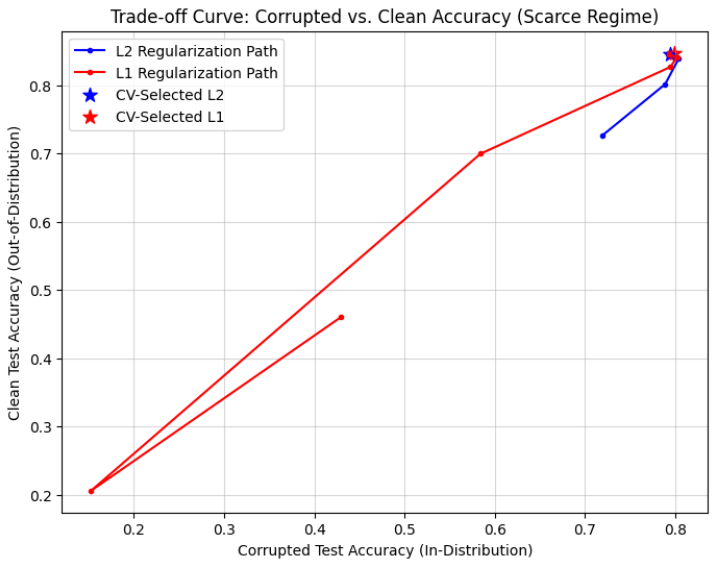

b) Os modelos selecionados por Validação Cruzada (CV) (marcados como estrelas no gráfico de trade-off - da alterantiva anterior) começam a cair exatamente no pico ideal da fronteira de trade-off. Eles estão posicionados no extremo canto superior direito das curvas. Esse é o ponto de equilíbrio onde o modelo atinge sua acurácia máxima possível tanto para os dados corrompidos quanto para os dados limpos, simultaneamente, logo antes de ocorrer qualquer queda de desempenho. Isso indica que a CV foi extremamente eficaz em identificar o melhor modelo, mesmo sem acesso ao teste limpo. 

A CV conseguiu selecionar um modelo que generaliza muito bem para ambos os testes, o que é notável considerando que a seleção foi feita apenas com base no desempenho no conjunto corrompido. Esse resultado reforça a ideia de que a CV pode ser uma ferramenta poderosa para a seleção de modelos, desde que haja uma correlação entre o desempenho nos dados corrompidos e limpos, como evidenciado pela forma da curva de trade-off.

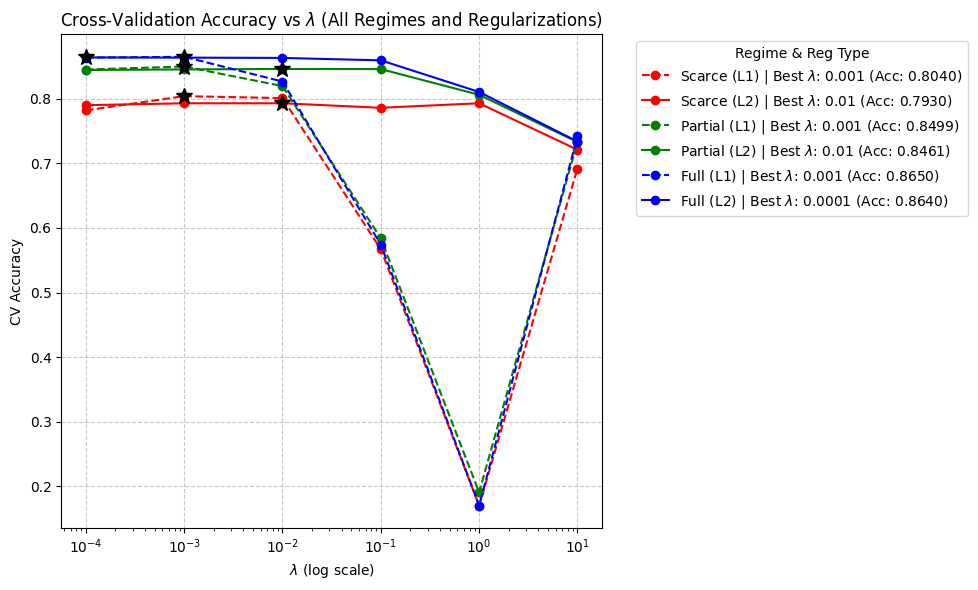

A resposta se mostra correta pois os resultados de melhor lambda se repete tanto na imagem de trade-off quanto na curva de acurácia por lambda, onde o melhor lambda para o dataset esparso para L2 é 10⁻2 e para L1 é 10⁻3 para ambos os casos, mostrando que o CV foi consistente e confiável.

c) A previsão inicial era de que o modelo treinado com o dataset esparso sofreria overfitting, decorando o ruído aleatório presente nas amostras, e apresentaria uma performance ruim no teste limpo. De fato, a acurácia do modelo esparso no teste limpo é significativamente menor do que a dos outros modelos, confirmando a hipótese de overfitting. O que as imagens dos pesos não revelaram completamente foi a extensão do impacto do ruído no modelo esparso: embora os pesos mostrem um padrão ruidoso, eles não indicam claramente o quão mal o modelo generaliza para dados limpos, o que ficou evidente apenas na avaliação do teste.

d) Avaliamos pela tabela de Evaluation do CV:

--- Evaluating Final CV-Selected Models ---

[Scarce | L1] Acc Corr: 0.7987 | Acc Clean: 0.8471 | Sparsity: 49.23%

[Scarce | L2] Acc Corr: 0.7940 | Acc Clean: 0.8451 | Sparsity: 0.20%

[Partial | L1] Acc Corr: 0.8573 | Acc Clean: 0.8849 | Sparsity: 40.64%

[Partial | L2] Acc Corr: 0.8474 | Acc Clean: 0.8822 | Sparsity: 0.19%

[Full | L1] Acc Corr: 0.8857 | Acc Clean: 0.8963 | Sparsity: 50.70%

[Full | L2] Acc Corr: 0.8767 | Acc Clean: 0.8963 | Sparsity: 0.22%

Temos que L1 tende a produzir soluções esparsas, onde muitos pesos são exatamente zero, gerando um seletor de features, olhando apenas para o real esqueleto do dígito, o que pode levar a uma melhor generalização em dados limpos, pois o modelo se torna mais simples e menos propenso a capturar ruídos específicos do conjunto de treinamento. Por outro lado, a regularização L2 penaliza os pesos de forma uniforme, o que pode resultar em um modelo mais complexo que diminui muito o ruído, mas ainda o captura em alguma escala, prejudicando a performance em dados limpos. Isso é evidenciado pela acurácia ligeiramente superior dos modelos L1 em comparação aos L2 no teste limpo, muito embora ambos tenham desempenho muito semelhante, L1 se mostrou superior.

e) Em um cenário de implantação real, onde o conjunto de teste limpo não estaria disponível durante a seleção do modelo. Para conseguirmos manter uma alta acurácia na detecção dos dígitos, poderíamos:
- Usar técnicas de validação robusta, como validação cruzada estratificada, para garantir que o modelo seja avaliado em diferentes subconjuntos do conjunto de treinamento corrompido. Isso ajuda a obter uma estimativa mais confiável do desempenho do modelo e a evitar overfitting ao ruído presente no conjunto de treinamento.
- Se soubermos que os dados reais são mais simples, podemos confiar mais no modelo L1, que tende a produzir soluções mais esparsas e menos propensas a capturar ruídos específicos do conjunto de treinamento, o que pode levar a uma melhor generalização em dados limpos.
- Poderíamos calcular os desvíos padrão da acurácia nos diferentes folds da validação cruzada para avaliar a estabilidade do modelo. Modelos com menor variância na acurácia entre os folds podem ser mais confiáveis para generalizar a dados limpos, mesmo sem acesso direto a um conjunto de teste limpo.
- Depois de treinar o modelo com o conjunto corrompido, poderíamos pegar o dataset e adicionar ainda mais ruídos e variações nas imagens. O modelo que conseguisse ainda sim generalizar com essas alterações provavelmente se sairia bem em classificar os dígitos limpos

In [53]:
for regime in ["Scarce", "Partial", "Full"]:
    print(f"\n{'='*65}")
    print(f"PROCESSANDO REGIME: {regime.upper()}")
    print(f"{'='*65}")

    X_raw, y_raw = data_regimes[regime]
    
    # 1. Obter resultados do CV usando a SUA função
    cv_curves = {"l1": {}, "l2": {}}
    best_lambdas = {"l1": None, "l2": None}
    
    for reg_type in ["l1", "l2"]:
        print(f"Rodando CV para {reg_type.upper()}...")
        best_lbd, results = run_kfold_cv(X_raw, y_raw, reg_type, k_splits, lambda_grid)
        best_lambdas[reg_type] = best_lbd
        cv_curves[reg_type] = results  # Dicionário com {lambda: cv_acc}

    # 2. Preparar os dados de Treino e Teste com o MESMO escalonamento (Prevenindo Data Leakage)
    print("Preparando e escalonando dados para teste final...")
    X_raw_flat = flatten_images(X_raw).astype(np.float32)
    mean = X_raw_flat.mean(axis=0, keepdims=True)
    std = X_raw_flat.std(axis=0, keepdims=True)
    std[std == 0] = 1.0
    
    # Treino
    X_train_t = torch.tensor((X_raw_flat - mean) / std, dtype=torch.float32)
    y_train_t = torch.tensor(y_raw, dtype=torch.long)
    
    # Escalonando os Testes com o "mean" e "std" do conjunto de TREINO atual!
    X_test_corr_flat_np = flatten_images(X_test_corr_flat).astype(np.float32)
    X_test_clean_flat_np = flatten_images(X_test_clean_flat).astype(np.float32)
    
    X_tc_t = torch.tensor((X_test_corr_flat_np - mean) / std, dtype=torch.float32)
    X_tcl_t = torch.tensor((X_test_clean_flat_np - mean) / std, dtype=torch.float32)
    
    # Liberando a memória (igual ao seu algoritmo)
    del X_raw_flat, X_test_corr_flat_np, X_test_clean_flat_np
    gc.collect()

    # 3. Treinar modelos finais para TODOS os lambdas (para achar o menor Test Gap)
    print("Calculando acurácias nos testes para encontrar Gaps...")
    test_results = {"l1": {"corr": [], "clean": []}, "l2": {"corr": [], "clean": []}}
    
    # Preparando tensores de label (y) para a função accuracy
    y_tc_t = torch.tensor(y_t_corr, dtype=torch.long)
    y_tcl_t = torch.tensor(y_t_clean, dtype=torch.long)
    
    for reg_type in ["l1", "l2"]:
        for lbd in lambda_grid:
            temp_model = LinearModel(input_dim=784, num_classes=10)
            l1_val = lbd if reg_type == 'l1' else 0.0
            l2_val = lbd if reg_type == 'l2' else 0.0
            
            # Treinamento com as mesmas iterações do seu modelo final (1000)
            train(temp_model, X_train_t, y_train_t, n_iter=1000, lr=0.1, l1=l1_val, l2=l2_val)
            
            with torch.no_grad():
                acc_corr = accuracy(temp_model(X_tc_t), y_tc_t)
                acc_clean = accuracy(temp_model(X_tcl_t), y_tcl_t)
                test_results[reg_type]["corr"].append(acc_corr)
                test_results[reg_type]["clean"].append(acc_clean)
            
            del temp_model
            gc.collect()

    # 4. Calcular Gaps e identificar os índices desejados
    gaps_l1 = [corr - clean for corr, clean in zip(test_results["l1"]["corr"], test_results["l1"]["clean"])]
    gaps_l2 = [corr - clean for corr, clean in zip(test_results["l2"]["corr"], test_results["l2"]["clean"])]
    
    # Índices matemáticos
    idx_min_gap_l1 = np.argmin([abs(g) for g in gaps_l1])
    idx_min_gap_l2 = np.argmin([abs(g) for g in gaps_l2])
    
    idx_best_cv_l1 = lambda_grid.index(best_lambdas["l1"])
    idx_best_cv_l2 = lambda_grid.index(best_lambdas["l2"])
    
    # Assumimos que o índice 0 da grid (0.0001) é o Baseline (Sem Regularização)
    idx_base = 0 
    
    # Extrai os arrays de valores de CV do dicionário `cv_curves` (garantindo a ordem da grid)
    cv_l1 = [cv_curves["l1"][lbd] for lbd in lambda_grid]
    cv_l2 = [cv_curves["l2"][lbd] for lbd in lambda_grid]

    # 5. Montar a Tabela
    dados_tabela = {
        "Model": [
            "No regularization (baseline)", 
            "Best CV, L2", 
            "Best CV, L1", 
            "Smallest in/out gap, L2", 
            "Smallest in/out gap, L1"
        ],
        "CV Accuracy": [
            cv_l2[idx_base], 
            cv_l2[idx_best_cv_l2],
            cv_l1[idx_best_cv_l1],
            cv_l2[idx_min_gap_l2],
            cv_l1[idx_min_gap_l1]
        ],
        "Test Acc (corrupted)": [
            test_results["l2"]["corr"][idx_base],
            test_results["l2"]["corr"][idx_best_cv_l2],
            test_results["l1"]["corr"][idx_best_cv_l1],
            test_results["l2"]["corr"][idx_min_gap_l2],
            test_results["l1"]["corr"][idx_min_gap_l1]
        ],
        "Test Acc (clean)": [
            test_results["l2"]["clean"][idx_base],
            test_results["l2"]["clean"][idx_best_cv_l2],
            test_results["l1"]["clean"][idx_best_cv_l1],
            test_results["l2"]["clean"][idx_min_gap_l2],
            test_results["l1"]["clean"][idx_min_gap_l1]
        ],
        "Gap": [
            gaps_l2[idx_base],
            gaps_l2[idx_best_cv_l2],
            gaps_l1[idx_best_cv_l1],
            gaps_l2[idx_min_gap_l2],
            gaps_l1[idx_min_gap_l1]
        ]
    }
    
    df_summary = pd.DataFrame(dados_tabela)
    df_summary = df_summary.round(4) # Arredonda para 4 casas decimais como os seus prints
    
    print(f"\n--- SUMMARY TABLE: {regime} ---")
    print(df_summary.to_string(index=False))
    print("\n")


PROCESSANDO REGIME: SCARCE
Rodando CV para L1...
Iniciando treinamento( learning_rate = 0.1 ):
   - Época: 0/150 | loss = 2.426
   - Época: 50/150 | loss = 0.164
   - Época: 100/150 | loss = 0.091
Treinamento finalizado
Iniciando treinamento( learning_rate = 0.1 ):
   - Época: 0/150 | loss = 2.418
   - Época: 50/150 | loss = 0.169
   - Época: 100/150 | loss = 0.094
Treinamento finalizado
Iniciando treinamento( learning_rate = 0.1 ):
   - Época: 0/150 | loss = 2.424
   - Época: 50/150 | loss = 0.168
   - Época: 100/150 | loss = 0.093
Treinamento finalizado
Iniciando treinamento( learning_rate = 0.1 ):
   - Época: 0/150 | loss = 2.488
   - Época: 50/150 | loss = 0.168
   - Época: 100/150 | loss = 0.092
Treinamento finalizado
Iniciando treinamento( learning_rate = 0.1 ):
   - Época: 0/150 | loss = 2.435
   - Época: 50/150 | loss = 0.174
   - Época: 100/150 | loss = 0.095
Treinamento finalizado
Iniciando treinamento( learning_rate = 0.1 ):
   - Época: 0/150 | loss = 2.581
   - Época: 50/1

C:\Users\Master\AppData\Local\Temp\ipykernel_20288\3539984717.py:45: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  y_tc_t = torch.tensor(y_t_corr, dtype=torch.long)
C:\Users\Master\AppData\Local\Temp\ipykernel_20288\3539984717.py:46: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  y_tcl_t = torch.tensor(y_t_clean, dtype=torch.long)


   - Época: 200/1000 | loss = 0.069
   - Época: 250/1000 | loss = 0.062
   - Época: 300/1000 | loss = 0.057
   - Época: 350/1000 | loss = 0.054
   - Época: 400/1000 | loss = 0.052
   - Época: 450/1000 | loss = 0.050
   - Época: 500/1000 | loss = 0.049
   - Época: 550/1000 | loss = 0.047
   - Época: 600/1000 | loss = 0.047
   - Época: 650/1000 | loss = 0.046
   - Época: 700/1000 | loss = 0.045
   - Época: 750/1000 | loss = 0.045
   - Época: 800/1000 | loss = 0.044
   - Época: 850/1000 | loss = 0.044
   - Época: 900/1000 | loss = 0.043
   - Época: 950/1000 | loss = 0.043
Treinamento finalizado
Iniciando treinamento( learning_rate = 0.1 ):
   - Época: 0/1000 | loss = 2.619
   - Época: 50/1000 | loss = 0.378
   - Época: 100/1000 | loss = 0.304
   - Época: 150/1000 | loss = 0.280
   - Época: 200/1000 | loss = 0.267
   - Época: 250/1000 | loss = 0.259
   - Época: 300/1000 | loss = 0.252
   - Época: 350/1000 | loss = 0.247
   - Época: 400/1000 | loss = 0.243
   - Época: 450/1000 | loss = 0.24

C:\Users\Master\AppData\Local\Temp\ipykernel_20288\3539984717.py:45: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  y_tc_t = torch.tensor(y_t_corr, dtype=torch.long)
C:\Users\Master\AppData\Local\Temp\ipykernel_20288\3539984717.py:46: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  y_tcl_t = torch.tensor(y_t_clean, dtype=torch.long)


   - Época: 50/1000 | loss = 0.525
   - Época: 100/1000 | loss = 0.421
   - Época: 150/1000 | loss = 0.371
   - Época: 200/1000 | loss = 0.340
   - Época: 250/1000 | loss = 0.318
   - Época: 300/1000 | loss = 0.301
   - Época: 350/1000 | loss = 0.288
   - Época: 400/1000 | loss = 0.277
   - Época: 450/1000 | loss = 0.267
   - Época: 500/1000 | loss = 0.259
   - Época: 550/1000 | loss = 0.252
   - Época: 600/1000 | loss = 0.246
   - Época: 650/1000 | loss = 0.240
   - Época: 700/1000 | loss = 0.235
   - Época: 750/1000 | loss = 0.230
   - Época: 800/1000 | loss = 0.226
   - Época: 850/1000 | loss = 0.222
   - Época: 900/1000 | loss = 0.219
   - Época: 950/1000 | loss = 0.215
Treinamento finalizado
Iniciando treinamento( learning_rate = 0.1 ):
   - Época: 0/1000 | loss = 2.653
   - Época: 50/1000 | loss = 0.673
   - Época: 100/1000 | loss = 0.585
   - Época: 150/1000 | loss = 0.550
   - Época: 200/1000 | loss = 0.531
   - Época: 250/1000 | loss = 0.519
   - Época: 300/1000 | loss = 0.510

C:\Users\Master\AppData\Local\Temp\ipykernel_20288\3539984717.py:45: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  y_tc_t = torch.tensor(y_t_corr, dtype=torch.long)
C:\Users\Master\AppData\Local\Temp\ipykernel_20288\3539984717.py:46: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  y_tcl_t = torch.tensor(y_t_clean, dtype=torch.long)


   - Época: 50/1000 | loss = 0.567
   - Época: 100/1000 | loss = 0.486
   - Época: 150/1000 | loss = 0.453
   - Época: 200/1000 | loss = 0.435
   - Época: 250/1000 | loss = 0.422
   - Época: 300/1000 | loss = 0.414
   - Época: 350/1000 | loss = 0.407
   - Época: 400/1000 | loss = 0.402
   - Época: 450/1000 | loss = 0.398
   - Época: 500/1000 | loss = 0.395
   - Época: 550/1000 | loss = 0.392
   - Época: 600/1000 | loss = 0.390
   - Época: 650/1000 | loss = 0.388
   - Época: 700/1000 | loss = 0.386
   - Época: 750/1000 | loss = 0.385
   - Época: 800/1000 | loss = 0.383
   - Época: 850/1000 | loss = 0.382
   - Época: 900/1000 | loss = 0.381
   - Época: 950/1000 | loss = 0.380
Treinamento finalizado
Iniciando treinamento( learning_rate = 0.1 ):
   - Época: 0/1000 | loss = 2.554
   - Época: 50/1000 | loss = 0.704
   - Época: 100/1000 | loss = 0.625
   - Época: 150/1000 | loss = 0.595
   - Época: 200/1000 | loss = 0.581
   - Época: 250/1000 | loss = 0.573
   - Época: 300/1000 | loss = 0.568

---

## Summary

Complete the table below with results from your experiments. Use the best model according to each criterion.

Como estamos tratando dos melhores valores e modelos, foram selecionados os modelos treinados com Full. Para encontrar o menor gap foram considerados outros valores de lambda que minimizavam o gap, não necessariamente os com maior accuracy.

| Model                              | CV Accuracy | Test Acc (corrupted) | Test Acc (clean) | Gap  |
|------------------------------------|-------------|----------------------|------------------|------|
| No regularization (baseline)       |      0.8625       |         0.8774        |       0.8966      |   -0.0192   |
| Best CV, L2                        |      0.8642       |         0.8804        |       0.8949      |   -0.0145   |
| Best CV, L1                        |      0.8655       |         0.8847        |       0.8962      |   -0.0115   |
| Smallest in/out gap, L2            |      0.8061       |         0.8188        |       0.8189      |    0.0001   |
| Smallest in/out gap, L1            |      0.1716       |         0.1477        |       0.1584      |    0.0107   |

*Gap = Test Acc (corrupted) - Test Acc (clean).*

Para encontrarmos os valores do CV Accuracy precisamos de mais uma divisão dos dados de treino, para ter a validação do k-fold, por isso uma pequena diferença das precisões dos treinamentos apresentados anteriormente. Para não haver confusão de onde cada valor está vindo, usaremos os valores quando usamos o 5-fold. Assim, a última celula retorna para a gente as tabelas:

--- SUMMARY TABLE: Scarce ---
|                       Model|  CV Accuracy|  Test Acc (corrupted)|  Test Acc (clean)|     Gap|
|----------------------------|-------------|----------------------|------------------|--------|
|No regularization (baseline)|        0.784|                0.7930|            0.8462| -0.0532|
|                 Best CV, L2|        0.795|                0.8033|            0.8373| -0.0340|
|                 Best CV, L1|        0.801|                0.7988|            0.8469| -0.0481|
|     Smallest in/out gap, L2|        0.721|                0.7186|            0.7256| -0.0070|
|     Smallest in/out gap, L1|        0.706|                0.1480|            0.1852| -0.0372|


--- SUMMARY TABLE: Partial ---
|                       Model|  CV Accuracy|  Test Acc (corrupted)|  Test Acc (clean)|     Gap|
|----------------------------|-------------|----------------------|------------------|--------|
|No regularization (baseline)|       0.8425|                0.8349|            0.8839| -0.0490|
|                 Best CV, L2|       0.8447|                0.8363|            0.8832| -0.0469|
|                 Best CV, L1|       0.8483|                0.8576|            0.8853| -0.0277|
|     Smallest in/out gap, L2|       0.8061|                0.8188|            0.8189| -0.0001|
|     Smallest in/out gap, L1|       0.1716|                0.1477|            0.1584| -0.0107|

--- SUMMARY TABLE: Full ---
|                       Model|  CV Accuracy|  Test Acc (corrupted)|  Test Acc (clean)|     Gap|
|----------------------------|-------------|----------------------|------------------|--------|
|No regularization (baseline)|       0.8625|                0.8774|            0.8966| -0.0192|
|                 Best CV, L2|       0.8642|                0.8804|            0.8949| -0.0145|
|                 Best CV, L1|       0.8655|                0.8847|            0.8962| -0.0115|
|     Smallest in/out gap, L2|       0.8105|                0.8232|            0.8193|  0.0039|
|     Smallest in/out gap, L1|       0.8655|                0.8847|            0.8962| -0.0115|



---

## Assignment Submission

This notebook must be filled with your solution and submitted on the Assignment's entry at our Google Classroom page.

Before submitting, verify that:
- The notebook runs end-to-end without errors (use **Run All** after restarting the kernel).
- All plots are rendered in the output.
- All written answers are filled in.
- The summary table is completed.
- AI usage declaration and prompts are included if applicable.

**Important: Only one member of the group should submit.**

### Policy for late submissions

You are NOT encouraged to submit after the deadline; however, in this case the following penalties apply:

- 25% deduction for 1-day late submission.
- 50% deduction for 2-day late submission.
- 75% deduction for 3-day late submission.